# P0: Environment Sanity Check

Verify RDKit molecule parsing, Morgan fingerprint generation, and molecule
visualization for ethylene carbonate.

RDKit version: 2026.03.6
Canonical SMILES: O=C1OCCO1
Morgan fingerprint shape: (2048,)
Set bits: 11
P0 gate: PASS


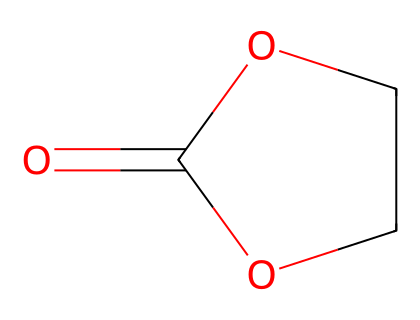

In [1]:
from pathlib import Path

from IPython.display import Image, display
from rdkit import Chem, rdBase
from rdkit.Chem import Draw, rdFingerprintGenerator

repository_root = Path.cwd()
while not (repository_root / "pyproject.toml").is_file():
    repository_root = repository_root.parent
artifact_dir = repository_root / "probes" / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

smiles = "C1COC(=O)O1"
molecule = Chem.MolFromSmiles(smiles)
assert molecule is not None

molecule_path = artifact_dir / "p0_ec_molecule.png"
Draw.MolToFile(molecule, molecule_path, size=(420, 320))

generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fingerprint = generator.GetFingerprint(molecule)
fingerprint_bits = list(fingerprint.GetOnBits())

print(f"RDKit version: {rdBase.rdkitVersion}")
print(f"Canonical SMILES: {Chem.MolToSmiles(molecule)}")
print(f"Morgan fingerprint shape: ({fingerprint.GetNumBits()},)")
print(f"Set bits: {len(fingerprint_bits)}")
print("P0 gate: PASS")
display(Image(filename=str(molecule_path)))